![](https://github.com/mccode-dev/PaNRAID/raw/main/images/toplogo-diadem.png)

# A short machine-learning workflow: scikit-learn and PyTorch

This notebook introduces the essential workflow for supervised **classification and regression** using small synthetic datasets. We first use **scikit-learn**, which handles optimization internally, and then **PyTorch**, where we write the training and validation loops explicitly.

The recurring steps are:

1. define examples `X` and targets `y`;
2. split into **training**, **validation**, and **test** sets;
3. fit preprocessing using training data only;
4. train on the training set;
5. use validation data for model choices;
6. evaluate once on the untouched test set.


In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## Create and inspect a synthetic dataset

Each row contains two numerical features. The target is class `0` or `1`. The curved class boundary makes this slightly more interesting than a linearly separable example.


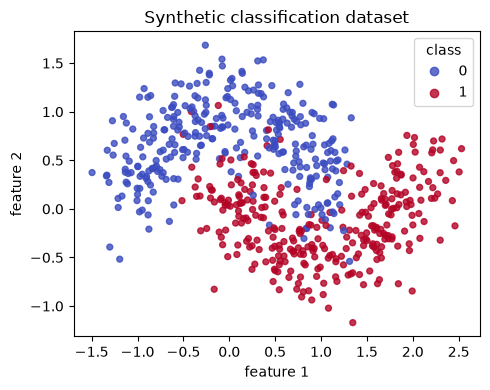

In [2]:
X, y = make_moons(n_samples=600, noise=0.25, random_state=SEED)

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=18, alpha=0.8)
ax.set(xlabel='feature 1', ylabel='feature 2', title='Synthetic classification dataset')
ax.legend(*scatter.legend_elements(), title='class')
plt.tight_layout()


## Split before training

The model learns parameters from the **training set**. The **validation set** supports choices such as model complexity or training duration. The **test set** estimates final performance and should not influence those choices. `stratify=y` preserves class proportions.


In [3]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=SEED
)  # 25% of 80% gives 20% of the full dataset

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)       # learn mean and scale here only
X_validation = scaler.transform(X_validation)
X_test = scaler.transform(X_test)

print('train:', X_train.shape, 'validation:', X_validation.shape, 'test:', X_test.shape)


train: (360, 2) validation: (120, 2) test: (120, 2)


## A brief [scikit-learn](https://scikit-learn.org/stable/) workflow

Scikit-learn is an open-source Python library for traditional machine learning, providing simple and consistent tools for data preprocessing, classification, regression, clustering, dimensionality reduction, model evaluation, and hyperparameter tuning. It includes algorithms such as random forests, support vector machines, and linear regression, all accessed through a common interface—typically fit() to train and predict() to make predictions—making it especially useful for quickly building and comparing machine-learning models on tabular data.

We'll showcase scikit-learn with Random Forests. A random forest classifier combines many decision trees to assign a category to an input. Each tree examines a random subset of the training data and its features, learns a sequence of simple rules, such as “Is the value greater than 10?”, and then Produces its own prediction.

The forest then combines all predictions through majority voting. For example, if 80 out of 100 trees predict class C,” the final prediction is "class C".

Using many diverse trees generally makes the prediction more accurate and robust than relying on a single decision tree. It also works well without extensive data preparation and can indicate which input features are most influential. However, the complete forest is harder to interpret than one decision tree.

<img src="https://miro.medium.com/v2/resize:fit:1200/1*hmtbIgxoflflJqMJ_UHwXw.jpeg" height=500 />

In [4]:
candidates = []
for max_depth in [3, 5, None]:
    model = RandomForestClassifier(
        n_estimators=100, max_depth=max_depth, random_state=SEED, n_jobs=-1
    )
    model.fit(X_train, y_train)
    validation_accuracy = model.score(X_validation, y_validation)
    candidates.append((validation_accuracy, max_depth, model))
    print(f'max_depth={str(max_depth):>4s}  validation accuracy={validation_accuracy:.3f}')

best_validation_accuracy, best_depth, sklearn_model = max(candidates, key=lambda row: row[0])
sklearn_predictions = sklearn_model.predict(X_test)
sklearn_test_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f'\nSelected max_depth={best_depth}; test accuracy={sklearn_test_accuracy:.3f}')


max_depth=   3  validation accuracy=0.925
max_depth=   5  validation accuracy=0.925
max_depth=None  validation accuracy=0.933

Selected max_depth=None; test accuracy=0.917


Scikit-learn is ideal for quick baselines and classical models. Its estimator API is usually `fit`, `predict`, and `score`. PyTorch exposes the optimization steps, making it suitable for neural networks and custom training procedures.

## Prepare [PyTorch](https://docs.pytorch.org/docs/2.14/pytorch-api.html) datasets and loaders

`PyTorch` is an open-source Python framework for building and training machine-learning models, particularly neural networks. It represents data and model parameters as multidimensional arrays called tensors, can perform computations efficiently on CPUs and GPUs, and automatically calculates the gradients needed to update a model during training. Its flexible, Python-friendly design makes it useful for both research and production applications, from image classification and language processing to scientific machine learning.

A `TensorDataset` pairs examples and targets. A `DataLoader` creates mini-batches. Training data are shuffled each epoch; validation and test data are not.


In [5]:
def tensor_dataset(features, targets):
    return TensorDataset(
        torch.tensor(features, dtype=torch.float32),
        torch.tensor(targets, dtype=torch.long),
    )

train_loader = DataLoader(tensor_dataset(X_train, y_train), batch_size=32, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
validation_loader = DataLoader(tensor_dataset(X_validation, y_validation), batch_size=64)
test_loader = DataLoader(tensor_dataset(X_test, y_test), batch_size=64)

features, targets = next(iter(train_loader))
print('feature batch:', features.shape, 'target batch:', targets.shape)


feature batch: torch.Size([32, 2]) target batch: torch.Size([32])


## Define a small neural network

A forward pass maps two input features to two class **logits**. `CrossEntropyLoss` compares logits with integer targets. The optimizer updates trainable parameters using gradients computed by backpropagation.


In [6]:
class SmallClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 4), nn.ReLU(),
            nn.Linear(4, 4), nn.ReLU(),
            nn.Linear(4, 2),
        )

    def forward(self, x):
        return self.network(x)

pytorch_model = SmallClassifier()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.005)
print('Trainable parameters:', sum(parameter.numel() for parameter in pytorch_model.parameters()))


Trainable parameters: 42


## Training and validation loops

During training we clear old gradients, run the model, calculate loss, backpropagate, and update parameters. Validation disables gradients and performs no updates. We retain the state with the lowest validation loss instead of automatically using the final epoch.


In [7]:
def run_epoch(model, loader, loss_function, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = total_correct = total_examples = 0

    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for features, targets in loader:
            logits = model(features)
            loss = loss_function(logits, targets)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_examples += targets.size(0)
            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()

    return total_loss / total_examples, total_correct / total_examples

history = []
best_validation_loss = float('inf')
best_state = None

for epoch in range(1, 51):
    train_loss, train_accuracy = run_epoch(pytorch_model, train_loader, loss_function, optimizer)
    validation_loss, validation_accuracy = run_epoch(pytorch_model, validation_loader, loss_function)
    history.append((train_loss, train_accuracy, validation_loss, validation_accuracy))

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_state = copy.deepcopy(pytorch_model.state_dict())

    if epoch == 1 or epoch % 10 == 0:
        print(f'Epoch {epoch:02d}: train loss={train_loss:.3f}, accuracy={train_accuracy:.3f}; '
              f'validation loss={validation_loss:.3f}, accuracy={validation_accuracy:.3f}')

pytorch_model.load_state_dict(best_state)


Epoch 01: train loss=0.686, accuracy=0.500; validation loss=0.672, accuracy=0.500
Epoch 10: train loss=0.350, accuracy=0.867; validation loss=0.311, accuracy=0.858
Epoch 20: train loss=0.309, accuracy=0.872; validation loss=0.262, accuracy=0.892
Epoch 30: train loss=0.261, accuracy=0.903; validation loss=0.224, accuracy=0.917
Epoch 40: train loss=0.204, accuracy=0.942; validation loss=0.197, accuracy=0.917
Epoch 50: train loss=0.178, accuracy=0.947; validation loss=0.187, accuracy=0.933


<All keys matched successfully>

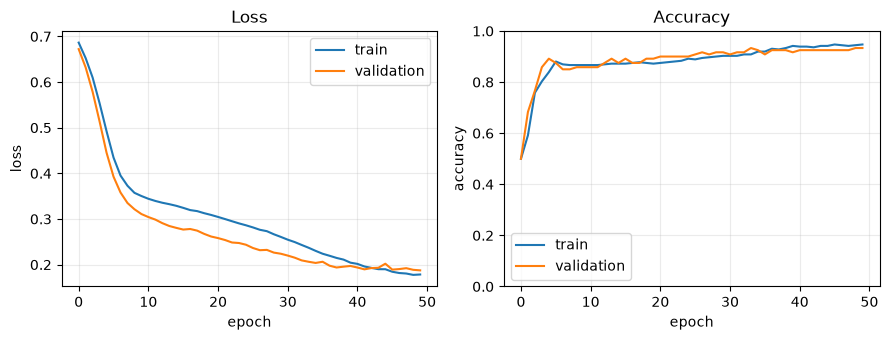

In [8]:
history = np.asarray(history)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(history[:, 0], label='train')
axes[0].plot(history[:, 2], label='validation')
axes[0].set(xlabel='epoch', ylabel='loss', title='Loss')
axes[1].plot(history[:, 1], label='train')
axes[1].plot(history[:, 3], label='validation')
axes[1].set(xlabel='epoch', ylabel='accuracy', ylim=(0, 1), title='Accuracy')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()


## Final test evaluation

Only now do we evaluate the selected PyTorch model on the test set. Accuracy is the fraction of correct predictions; a confusion matrix shows which classes are confused.


scikit-learn test accuracy: 0.917
PyTorch test accuracy:      0.917


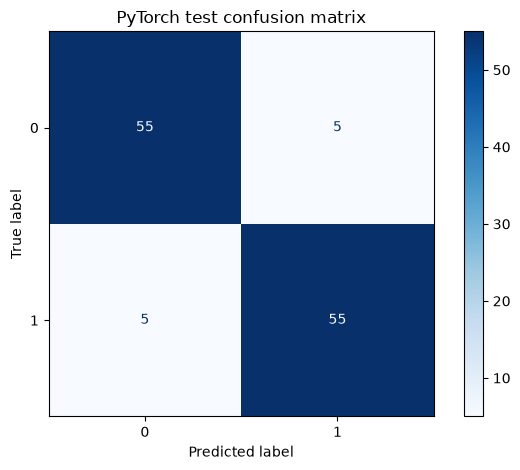

In [9]:
test_loss, pytorch_test_accuracy = run_epoch(pytorch_model, test_loader, loss_function)
with torch.inference_mode():
    pytorch_predictions = pytorch_model(torch.tensor(X_test, dtype=torch.float32)).argmax(1).numpy()

print(f'scikit-learn test accuracy: {sklearn_test_accuracy:.3f}')
print(f'PyTorch test accuracy:      {pytorch_test_accuracy:.3f}')

ConfusionMatrixDisplay.from_predictions(y_test, pytorch_predictions, cmap='Blues')
plt.title('PyTorch test confusion matrix')
plt.tight_layout()


## Visualize the learned classification boundaries

A decision boundary separates regions assigned to different classes. Both the random forest and neural network can learn nonlinear boundaries, but they partition feature space differently. The background shows each model's prediction; points are the observed examples.


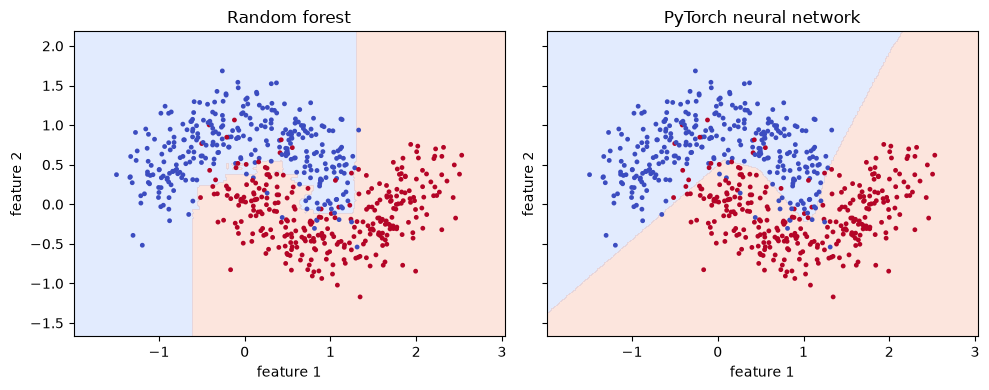

In [10]:
x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250)
x1 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250)
grid_x0, grid_x1 = np.meshgrid(x0, x1)
grid = np.column_stack([grid_x0.ravel(), grid_x1.ravel()])
scaled_grid = scaler.transform(grid)

sklearn_boundary = sklearn_model.predict(scaled_grid).reshape(grid_x0.shape)
with torch.inference_mode():
    pytorch_boundary = pytorch_model(torch.tensor(scaled_grid, dtype=torch.float32)).argmax(1)
pytorch_boundary = pytorch_boundary.numpy().reshape(grid_x0.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, boundary, title in zip(
    axes, [sklearn_boundary, pytorch_boundary], ['Random forest', 'PyTorch neural network']
):
    ax.contourf(grid_x0, grid_x1, boundary, levels=[-0.5, 0.5, 1.5], cmap='coolwarm', alpha=0.25)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=12, edgecolor='none')
    ax.set(xlabel='feature 1', ylabel='feature 2', title=title)
plt.tight_layout()


## Regression: predict a continuous value

Classification predicts a discrete class; regression predicts a number. Here the target follows a noisy nonlinear function containing oscillation and curvature. We retain the same split discipline, replace classification accuracy with regression metrics, and use mean squared error as the PyTorch loss. **RMSE** is an error in target units (lower is better); **R²** measures explained variation (closer to 1 is better).


In [11]:
rng = np.random.default_rng(SEED)
X_regression = rng.uniform(-3, 3, size=(400, 1))
x_values = X_regression[:, 0]
y_regression = np.sin(2 * x_values) + 0.3 * x_values**2 + rng.normal(0, 0.25, size=400)

Xr_train_val, Xr_test, yr_train_val, yr_test = train_test_split(
    X_regression, y_regression, test_size=0.20, random_state=SEED
)
Xr_train, Xr_validation, yr_train, yr_validation = train_test_split(
    Xr_train_val, yr_train_val, test_size=0.25, random_state=SEED
)
regression_scaler = StandardScaler().fit(Xr_train)
Xr_train = regression_scaler.transform(Xr_train)
Xr_validation = regression_scaler.transform(Xr_validation)
Xr_test = regression_scaler.transform(Xr_test)
print('train:', Xr_train.shape, 'validation:', Xr_validation.shape, 'test:', Xr_test.shape)


train: (240, 1) validation: (80, 1) test: (80, 1)


In [12]:
sklearn_regressor = RandomForestRegressor(
    n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1
).fit(Xr_train, yr_train)
validation_prediction = sklearn_regressor.predict(Xr_validation)
test_prediction = sklearn_regressor.predict(Xr_test)
print(f'scikit-learn validation RMSE: {mean_squared_error(yr_validation, validation_prediction) ** 0.5:.3f}')
print(f'scikit-learn test RMSE:       {mean_squared_error(yr_test, test_prediction) ** 0.5:.3f}')
print(f'scikit-learn test R²:          {r2_score(yr_test, test_prediction):.3f}')


scikit-learn validation RMSE: 0.313
scikit-learn test RMSE:       0.303
scikit-learn test R²:          0.911


In [13]:
def regression_loader(features, targets, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(features, dtype=torch.float32),
        torch.tensor(targets[:, None], dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=32, shuffle=shuffle)

regression_train_loader = regression_loader(Xr_train, yr_train, shuffle=True)
regression_validation_loader = regression_loader(Xr_validation, yr_validation)
regression_test_loader = regression_loader(Xr_test, yr_test)
regression_model = nn.Sequential(
    nn.Linear(1, 32), nn.Tanh(),
    nn.Linear(32, 32), nn.Tanh(),
    nn.Linear(32, 1),
)
regression_loss = nn.MSELoss()
regression_optimizer = torch.optim.Adam(regression_model.parameters(), lr=0.01)

def regression_epoch(model, loader, optimizer=None):
    model.train(optimizer is not None)
    squared_error = examples = 0
    context = torch.enable_grad() if optimizer is not None else torch.inference_mode()
    with context:
        for features, targets in loader:
            prediction = model(features)
            loss = regression_loss(prediction, targets)
            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            squared_error += loss.item() * targets.size(0)
            examples += targets.size(0)
    return (squared_error / examples) ** 0.5

best_regression_loss, best_regression_state = float('inf'), None
for epoch in range(1, 201):
    train_rmse = regression_epoch(regression_model, regression_train_loader, regression_optimizer)
    validation_rmse = regression_epoch(regression_model, regression_validation_loader)
    if validation_rmse < best_regression_loss:
        best_regression_loss = validation_rmse
        best_regression_state = copy.deepcopy(regression_model.state_dict())
regression_model.load_state_dict(best_regression_state)
pytorch_regression_rmse = regression_epoch(regression_model, regression_test_loader)
with torch.inference_mode():
    pytorch_regression_prediction = regression_model(torch.tensor(Xr_test, dtype=torch.float32)).numpy()[:, 0]
print(f'PyTorch validation RMSE: {best_regression_loss:.3f}')
print(f'PyTorch test RMSE:       {pytorch_regression_rmse:.3f}')
print(f'PyTorch test R²:          {r2_score(yr_test, pytorch_regression_prediction):.3f}')


PyTorch validation RMSE: 0.263
PyTorch test RMSE:       0.281
PyTorch test R²:          0.923


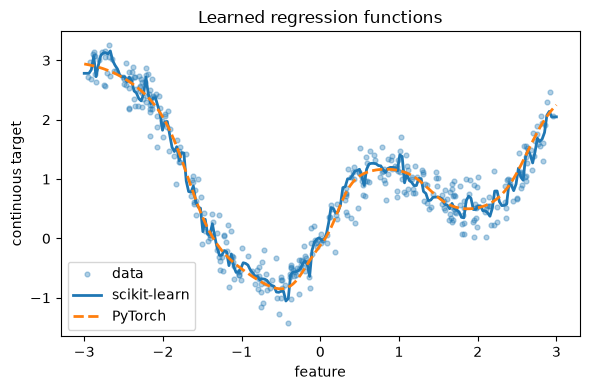

In [14]:
regression_grid = np.linspace(-3, 3, 200)[:, None]
scaled_regression_grid = regression_scaler.transform(regression_grid)
sklearn_line = sklearn_regressor.predict(scaled_regression_grid)
with torch.inference_mode():
    pytorch_line = regression_model(torch.tensor(scaled_regression_grid, dtype=torch.float32)).numpy()[:, 0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_regression[:, 0], y_regression, s=12, alpha=0.35, label='data')
ax.plot(regression_grid[:, 0], sklearn_line, linewidth=2, label='scikit-learn')
ax.plot(regression_grid[:, 0], pytorch_line, '--', linewidth=2, label='PyTorch')
ax.set(xlabel='feature', ylabel='continuous target', title='Learned regression functions')
ax.legend()
plt.tight_layout()


## Optional: tune the classifier with Optuna

The weights inside a neural network are learned by backpropagation. Choices made *about* training—such as hidden-layer width, learning rate, and batch size—are **hyperparameters**. [Optuna](https://optuna.readthedocs.io/) can search these choices automatically. Each trial proposes values, trains a fresh model on the training set, and reports validation accuracy. The test set must not be used by the Optuna objective.

This deliberately small study demonstrates the workflow; 12 trials do not constitute an exhaustive search. If Optuna is unavailable, install it in the notebook environment with `python -m pip install optuna`, restart the kernel if necessary, and rerun this section.


In [15]:
import optuna

# Keep the classroom output readable.
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Optuna:', optuna.__version__)


Optuna: 5.0.0


In [16]:
class TunableClassifier(nn.Module):
    def __init__(self, hidden_units):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_units), nn.ReLU(),
            nn.Linear(hidden_units, hidden_units), nn.ReLU(),
            nn.Linear(hidden_units, 2),
        )

    def forward(self, features):
        return self.network(features)

def fit_candidate(parameters, epochs=30):
    # Use the same initialization seed so trials differ mainly in their hyperparameters.
    torch.manual_seed(SEED)
    
    model = TunableClassifier(parameters['hidden_units'])
    
    optimizer = torch.optim.Adam(model.parameters(), lr=parameters['learning_rate'])
    
    trial_train_loader = DataLoader(
        tensor_dataset(X_train, y_train),
        batch_size=parameters['batch_size'], shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )

    best_accuracy = 0.0
    best_loss = float('inf')
    best_state = None
    for _ in range(epochs):
        run_epoch(model, trial_train_loader, loss_function, optimizer)
        validation_loss, validation_accuracy = run_epoch(
            model, validation_loader, loss_function
        )
        if validation_loss < best_loss:
            best_loss = validation_loss
            best_accuracy = validation_accuracy
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return model, best_accuracy

def objective(trial):
    parameters = {
        'hidden_units': trial.suggest_categorical('hidden_units', [4, 8, 16, 32]),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
    }
    _, validation_accuracy = fit_candidate(parameters, epochs=30)
    return validation_accuracy

Best validation accuracy: 0.958
Best hyperparameters: {'hidden_units': 32, 'learning_rate': 0.007359543748006599, 'batch_size': 16}


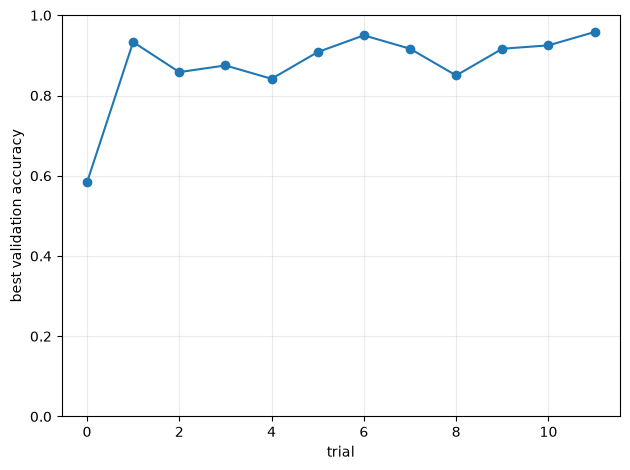

In [17]:
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=12)

print(f'Best validation accuracy: {study.best_value:.3f}')
print('Best hyperparameters:', study.best_params)

completed_trials = [trial for trial in study.trials if trial.value is not None]
plt.plot(
    [trial.number for trial in completed_trials],
    [trial.value for trial in completed_trials],
    'o-',
)
plt.xlabel('trial')
plt.ylabel('best validation accuracy')
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.tight_layout()


Optuna has selected hyperparameters using validation data only. We now train one fresh model with those choices and evaluate it once on the test set. In a larger project, repeat the complete study with multiple random seeds and record the search space, number of trials, and computational budget. Hyperparameter tuning can otherwise overfit the validation set just as model training can overfit the training set.


In [18]:
optimized_model, optimized_validation_accuracy = fit_candidate(
    study.best_params, epochs=50
)
optimized_test_loss, optimized_test_accuracy = run_epoch(
    optimized_model, test_loader, loss_function
)
print(f'Optimized validation accuracy: {optimized_validation_accuracy:.3f}')
print(f'Optimized test accuracy:       {optimized_test_accuracy:.3f}')


Optimized validation accuracy: 0.958
Optimized test accuracy:       0.908


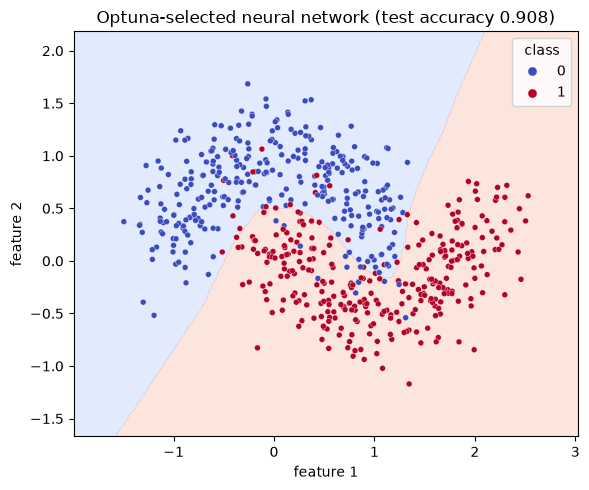

In [19]:
# Visualize how the Optuna-selected classifier fits the moon-shaped classes.
x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
x1 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
grid_x0, grid_x1 = np.meshgrid(x0, x1)
grid = np.column_stack((grid_x0.ravel(), grid_x1.ravel()))
scaled_grid = scaler.transform(grid)

optimized_model.eval()
with torch.inference_mode():
    boundary = optimized_model(
        torch.tensor(scaled_grid, dtype=torch.float32)
    ).argmax(dim=1).numpy()
boundary = boundary.reshape(grid_x0.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(
    grid_x0, grid_x1, boundary,
    levels=[-0.5, 0.5, 1.5], cmap='coolwarm', alpha=0.25,
)
scatter = ax.scatter(
    X[:, 0], X[:, 1], c=y, cmap='coolwarm',
    s=18, edgecolor='white', linewidth=0.25,
)
ax.set(
    xlabel='feature 1', ylabel='feature 2',
    title=f'Optuna-selected neural network (test accuracy {optimized_test_accuracy:.3f})',
)
ax.legend(*scatter.legend_elements(), title='class')
plt.tight_layout()
